# Concept Grounding & Interpretability with CLIP

This notebook explores **concept-based interpretability** for vision–language models (VLMs), using **CLIP** as a representative example.

We focus on understanding *why* a model associates an image with certain text concepts, by inspecting internal representations rather than just outputs.


## Objectives

By the end of this notebook, you should be able to:

- Understand how CLIP aligns visual and textual concepts
- Extract intermediate embeddings from the model
- Perform concept grounding using text prompts
- Interpret similarity scores from a representation-level perspective


## How This Works (High-Level)

CLIP is trained to align images and text in a shared embedding space.

1. Images are encoded into a visual embedding
2. Text prompts are encoded into a text embedding
3. Similarity (cosine similarity) determines alignment

Interpretability comes from *probing and comparing these embeddings* rather than relying only on final predictions.


## Connection to Interpretability

Unlike post-hoc saliency maps, concept-based analysis:

- Operates in representation space
- Can compare multiple competing concepts
- Is model-agnostic once embeddings are extracted

This makes it especially suitable for large vision–language models.


# Explainable AI with gradCAM

We focus on CLIP-based image classification to illustrate the conceptual difference between representation alignment and gradient-based visual attribution. Extensions to detection and segmentation are omitted for clarity.

In [1]:
import argparse
import os
import cv2
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

from transformers import CLIPProcessor, CLIPModel

from pytorch_grad_cam import (
    GradCAM,
    ScoreCAM,
    GradCAMPlusPlus,
    AblationCAM,
    XGradCAM,
    EigenCAM,
    EigenGradCAM,
    LayerCAM,
    FullGrad,
)
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.ablation_layer import AblationLayerVit


In [2]:
# Helper function to reshape tensor
def reshape_transform(tensor, height=16, width=16):
    result = tensor[:, 1:, :].reshape(tensor.size(0),
                                      height, width, tensor.size(2))

    # Bring the channels to the first dimension,
    # like in CNNs.
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Define the Image Classifier using CLIP
class ImageClassifier(nn.Module):
    # Initialize the model
    def __init__(self, labels, cache_dir=None):
        super(ImageClassifier, self).__init__()

        # Load the pre-trained CLIP model and processor
        self.clip = CLIPModel.from_pretrained(
            "openai/clip-vit-large-patch14",
            cache_dir=cache_dir
        )
        self.processor = CLIPProcessor.from_pretrained(
            "openai/clip-vit-large-patch14",
            cache_dir=cache_dir
        )

        self.labels = labels

    # Define the forward pass
    def forward(self, x):
        # Process the text inputs
        text_inputs = self.processor(
            text=self.labels,
            return_tensors="pt",
            padding=True
        )
        # Get the model outputs
        outputs = self.clip(
            pixel_values=x,
            input_ids=text_inputs["input_ids"].to(self.clip.device),
            attention_mask=text_inputs["attention_mask"].to(self.clip.device)
        )
        # Get the logits per image
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)
        # Return the probabilities
        for label, prob in zip(self.labels, probs[0]):
            print(f"{label}: {prob:.4f}")

        return probs

In [4]:
# =====================
# Configuration
# =====================

DEVICE = "cuda"  # or "cuda"
IMAGE_PATH = "./data/dog.jpeg"
LABELS = ["a cat", "a dog", "a car", "a person", "a shoe"]

METHOD = "eigencam"  # gradcam | gradcam++ | scorecam | xgradcam | ablationcam | eigencam | eigengradcam | layercam | fullgrad

AUG_SMOOTH = False
EIGEN_SMOOTH = False

print(f'Using device "{DEVICE}"')

Using device "cuda"


In [5]:
# CAM method selection
CAM_METHODS = {
    "gradcam": GradCAM,
    "scorecam": ScoreCAM,
    "gradcam++": GradCAMPlusPlus,
    "ablationcam": AblationCAM,
    "xgradcam": XGradCAM,
    "eigencam": EigenCAM,
    "eigengradcam": EigenGradCAM,
    "layercam": LayerCAM,
    "fullgrad": FullGrad
}

if METHOD not in CAM_METHODS:
    raise ValueError(f"METHOD must be one of {list(CAM_METHODS.keys())}")

In [ ]:
CACHE_DIR = "/projects/aixpert/users/aravind/cache"
# Model initialization
model = ImageClassifier(
    labels=LABELS,
    cache_dir=CACHE_DIR
).to(torch.device(DEVICE)).eval()
print(model)

target_layers = [
    model.clip.vision_model.encoder.layers[-1].layer_norm1
]

In [7]:
# Image preprocessing
rgb_img = cv2.imread(IMAGE_PATH, 1)[:, :, ::-1]
rgb_img = cv2.resize(rgb_img, (224, 224))
rgb_img = np.float32(rgb_img) / 255.0

input_tensor = preprocess_image(
    rgb_img,
    mean=[0.5, 0.5, 0.5],
    std=[0.5, 0.5, 0.5]
).to(DEVICE)

In [8]:
# Create CAM object
if METHOD == "ablationcam":
    cam = CAM_METHODS[METHOD](
        model=model,
        target_layers=target_layers,
        reshape_transform=reshape_transform,
        ablation_layer=AblationLayerVit()
    )
else:
    cam = CAM_METHODS[METHOD](
        model=model,
        target_layers=target_layers,
        reshape_transform=reshape_transform
    )

cam.batch_size = 32

In [9]:
# If None, CAM is generated for highest scoring category
targets = None

# Generate CAM
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets,
    eigen_smooth=EIGEN_SMOOTH,
    aug_smooth=AUG_SMOOTH
)

grayscale_cam = grayscale_cam[0]

a cat: 0.0029
a dog: 0.9948
a car: 0.0004
a person: 0.0019
a shoe: 0.0001


(-0.5, 223.5, 223.5, -0.5)

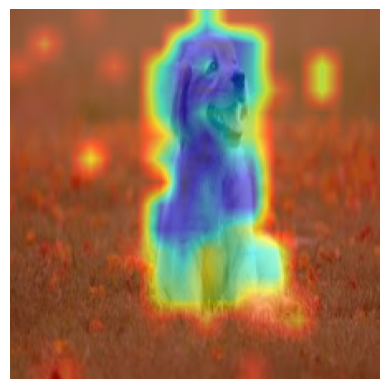

In [10]:
# Overlay CAM on image
cam_image = show_cam_on_image(rgb_img, grayscale_cam)
# Display the image
plt.imshow(cam_image)
plt.axis("off")

### Explanation

CLIP aligns images and text in a shared embedding space.
The model encodes the image and each text prompt, then computes cosine similarity between embeddings. The highest similarity determines the predicted label.

In this example:

* **“a dog”** receives probability ≈ 0.995
* Other labels receive near-zero probability

Grad-CAM (EigenCAM here) is then applied to the final vision layer to visualize which image regions most contributed to the similarity score for the top label.

The heatmap shows:

* Strong activation around the dog’s body and face
* Low activation in background regions

This means the model’s decision is spatially grounded in the object itself.

Important distinction:

* **CLIP similarity → representation-level alignment**
* **Grad-CAM → gradient-based spatial attribution**

Grad-CAM explains *where* the model looked.
Embedding similarity explains *why* the image matches a concept.

### Reflection & Concept Check

#### 1️. Thought Experiment

**Why does CLIP not need a traditional classification head?**

**Answer:**
CLIP does not learn class-specific weights.
Instead, it compares image embeddings with text embeddings.
Classification emerges from similarity in a shared space rather than from a learned linear classifier.

#### 2. Challenge

**If the label list included “a wolf” in addition to “a dog,” what might happen?**

**Answer:**

* Probabilities would redistribute across semantically similar concepts.
* The model might assign non-trivial probability to both.
* Grad-CAM heatmaps could look similar for both labels.

This reveals that CLIP decisions depend on embedding geometry — not discrete class boundaries.

#### 3. Thought Experiment

**Why might Grad-CAM highlight background regions in some cases?**

**Answer:**

Because the model may rely on contextual cues:

* Grass → outdoor scene
* Leash → pet context
* Furniture → indoor setting

Gradients reflect whatever increases similarity score — even if that cue is spurious.

#### 4. Deeper Conceptual Question

**Does Grad-CAM explain CLIP’s multimodal reasoning?**

**Answer:**

Not fully.

Grad-CAM explains spatial influence within the vision encoder.
It does not explain:

* Text embedding structure
* Cross-modal alignment geometry
* Why certain concepts are close in embedding space

It is a spatial attribution method, not a representation-level concept explanation.

## References
1. Chen, Hong-You, et al. "Contrastive localized language-image pre-training." arXiv preprint arXiv:2410.02746 (2024).
2. Selvaraju, Ramprasaath R., et al. "Grad-cam: Visual explanations from deep networks via gradient-based localization." Proceedings of the IEEE international conference on computer vision. 2017.
3. Muhammad, Mohammed Bany, and Mohammed Yeasin. "Eigen-cam: Class activation map using principal components." 2020 international joint conference on neural networks (IJCNN). IEEE, 2020.